In [ ]:
pip install opencv-python

In [ ]:
!conda install matplotlib -y

In [ ]:
pip install tensorflow-

# INITIAL SETUP
Imports, fixed variables etc.

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.optimizers import Adam # AdamW(?)
from tensorflow.keras.utils import Sequence, to_categorical
from sklearn.model_selection import train_test_split

import pandas as pd
import numpy as np
import cv2
import os
import glob
import xml.etree.ElementTree as ET # For parsing PASCAL VOC annotations

IMG_DIR = "RDD_Dataset/images/"
ANNOT_DIR = "RDD_Dataset/annotations/xmls/"
IMG_SIZE = (224, 224)
BATCH_SIZE = (32)
NUM_CLASSES = 4 #Gemini uses 4, why? (error?)
EPOCHS = 20 # Subject to change

# Mapping from class name (string) to integer
CLASS_MAP = {
    "D00": 0,
    "D10": 1,
    "D20": 2,
    "D40": 3
}

# Inverse mapping
INT_TO_CLASS = {v: k for k, v in CLASS_MAP.items()}

## Parsing annotations
Parse annotations to its corresponding image

In [ ]:
# Annotation parsing (image and xml)
# Parses all PASCAL VOC XML annotations --> returns a list of dictionaries
def parse_annotations(annot_dir, img_dir, class_map):
    data_list = []
    xml_files = glob.glob(os.path.join(annot_dir, "*.xml"))
    if not xml_files:
        print(f"Error: No XML files found in {annot_dir}!")
        return []

    print(f"Found {len(xml_files)} XML files!")

    # Check through dataset for specific counts
    img_not_found_count = 0
    parsing_errors = 0
    annotations_found = 0
    annotations_skipped = 0

    for xml_file in xml_files:
        try:
            tree = ET.parse(xml_file)
            root = tree.getroot()

            img_filename = root.find('filename').text
            img_path = os.path.join(img_dir, img_filename)

            if not os.path.exists(img_path):
                img_not_found_count += 1
                print(f"Warning! Image file not found {img_path}.")
                continue

            size = root.find('size')
            original_width = int(size.find('width').text)
            original_height = int(size.find('height').text)

            for obj in root.findall('object'):
                class_name = obj.find('name').text

                if class_name in class_map:
                    annotations_found += 1
                    bndbox = obj.find('bndbox')

                    # Get original bounding box coordinates (Apply min/max)
                    xmin = max(0, int(bndbox.find('xmin').text))
                    ymin = max(0, int(bndbox.find('ymin').text))
                    xmax = min(original_width, int(bndbox.find('xmax').text))
                    ymax = min(original_height, int(bndbox.find('ymax').text))

                    if xmax <= xmin or ymax <= ymin:
                        # Check for "bad" bounding box label (impossible coordinates)
                        print(f"Warning! Invalid bbox in {xml_file}.")
                        continue

                    # Append the data to data_list
                    data_list.append({
                        "image_path": img_path,
                        "original_width": original_width,
                        "original_height": original_height,
                        "class_name": class_name,
                        "class_int": class_map[class_name],
                        "bbox_original": [xmin, ymin, xmax, ymax]
                    })
                else:
                    annotations_skipped += 1

        except Exception as e:
            parsing_errors += 1
            print(f"Error parsing {xml_file}: {e}")

    print(f"Parsing complete. Found {len(data_list)} valid damage annotations.")
    print(f"Total annotations found: {annotations_found}")
    print(f"Total annotations skipped: {annotations_skipped}")
    print(f"Image files not found: {img_not_found_count}")
    print(f"XML parsing errors: {parsing_errors}")

    return data_list

In [ ]:
import pprint

# Testing parse_annotations
# To be deleted after project is finalized, used for checking only
raw_data = parse_annotations(ANNOT_DIR, IMG_DIR, CLASS_MAP)

if raw_data:
    print(f"\nSuccessfully parsed {len(raw_data)} damage annotations.")

    # --- 3a. Check the first 5 entries ---
    print("\n--- Example: First 5 Entries ---")
    pprint.pprint(raw_data[:5])

    # --- 3b. Check the class distribution (Answers your question!) ---
    print("\n--- Class Distribution Summary ---")
    df = pd.DataFrame(raw_data)
    print(df['class_name'].value_counts())
else:
    print("\nTest Failed: No data was returned.")

Found 30224 XML files!
Warning! Invalid bbox in RDD_Dataset/annotations/xmls/Japan_001265.xml.
Parsing complete. Found 43777 valid damage annotations.
Total annotations found: 43778
Total annotations skipped: 10705
Image files not found: 0
XML parsing errors: 0

Successfully parsed 43777 damage annotations.

--- Example: First 5 Entries ---
[{'bbox_original': [241, 404, 459, 567],
  'class_int': 0,
  'class_name': 'D00',
  'image_path': 'RDD_Dataset/images/Japan_008353.jpg',
  'original_height': 600,
  'original_width': 600},
 {'bbox_original': [82, 470, 202, 550],
  'class_int': 0,
  'class_name': 'D00',
  'image_path': 'RDD_Dataset/images/United_States_001833.jpg',
  'original_height': 640,
  'original_width': 640},
 {'bbox_original': [477, 538, 717, 720],
  'class_int': 2,
  'class_name': 'D20',
  'image_path': 'RDD_Dataset/images/India_005410.jpg',
  'original_height': 720,
  'original_width': 720},
 {'bbox_original': [501, 571, 677, 720],
  'class_int': 0,
  'class_name': 'D00',
 

## Load Images
Resizing, normalization etc.

In [ ]:
# Class for minor augmentation only (Resizing and normalization)
class RDD_DataGenerator1(Sequence):
    # Necessary since there are 2 outputs (class & bbox)
    # Required to resize both image and bounding box
    def __init__(self, dataframe, batch_size, target_size, num_classes, shuffle=True):
        self.df = dataframe
        self.batch_size = batch_size
        self.target_size = target_size
        self.num_classes = num_classes
        self.shuffle = shuffle
        self.indices = np.arange(len(self.df))
        self.on_epoch_end()

    def __len__(self):
        """To return number of batches per epoch"""
        return int(np.floor(len(self.df) / self.batch_size))

    def on_epoch_end(self):
        """Shuffle indices after each epoch"""
        # Prevents model from 'memorizing' the pattern
        # Helps model to LEARN actual features of the images
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __getitem__(self, index):
        """Generates one batch of data"""
        # Get indices for the current batch
        batch_indices = self.indices[index*self.batch_size : (index + 1) * self.batch_size]
        batch_df = self.df.iloc[batch_indices] # Get corresponding data rows from df

        # Initialize batch arrays first
        X = np.zeros((self.batch_size, *self.target_size, 3), dtype = np.float32)
        y_class = np.zeros((self.batch_size, self.num_classes), dtype = np.float32)
        y_loc = np.zeros((self.batch_size, 4), dtype = np.float32)

        for i, row in enumerate(batch_df.itertuples()):
            # Load image
            img = cv2.imread(row.image_path)
            if img is None:
                img = cv2.zeros((*self.target_size, 3))

            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Converts images to RGB format
            resized_img = cv2.resize(img, self.target_size)

            # Normalizing pixels to [0, 1] values
            X[i] = resized_img / 255.0

            # Scale and Normalize Bounding Box (IMPORTANT!!)
            original_bbox = row.bbox_original # xmin, ymin, xmax, ymax

            # Calculate the scaling factors
            x_scale = self.target_size[1] / row.original_width
            y_scale = self.target_size[0] / row.original_height

            # Apply the scaling feature onto the original bbox coordinates
            scaled_xmin = original_bbox[0] * x_scale
            scaled_ymin = original_bbox[1] * y_scale
            scaled_xmax = original_bbox[2] * x_scale
            scaled_ymax = original_bbox[3] * y_scale

            # Normalization to [0, 1] values for the sigmoid output layer (probability distribution)
            norm_xmin = scaled_xmin / self.target_size[1]
            norm_ymin = scaled_ymin / self.target_size[0]
            norm_xmax = scaled_xmax / self.target_size[1]
            norm_ymax = scaled_ymax / self.target_size[0]

            # Assigned the normalized values to the localization batch
            # Order: xmin, ymin, xmax, ymax
            y_loc[i] = [norm_xmin, norm_ymin, norm_xmax, norm_ymax]

            # One-Hot Encoder for the class label
            y_class[i] = to_categorical(row.class_int, num_classes=self.num_classes)

        # Now return the batch in a Keras expected format (used for multi-output model)
        return X, {'classification_output': y_class, 'localization_output': y_loc}

In [ ]:
# Class for more major augmentations (flipping, brightness/contrast)
class RDD_DataGenerator2(Sequence):
    def __init__(self, dataframe, batch_size, target_size, num_classes, shuffle=True, augment=True):
        self.df = dataframe
        self.batch_size = batch_size
        self.target_size = target_size
        self.num_classes = num_classes
        self.shuffle = shuffle
        self.augment = augment # Can be modified to augment(True) or not(False)
        self.indices = np.arange(len(self.df))
        self.on_epoch_end()

    def __len__(self):
        return int(np.floor(len(self.df) / self.batch_size))

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __getitem__(self, index):
        batch_indices = self.indices[index * self.batch_size : (index + 1) * self.batch_size]
        batch_df = self.df.iloc[batch_indices]

        X = np.zeros((self.batch_size, *self.target_size, 3), dtype=np.float32)
        y_class = np.zeros((self.batch_size, self.num_classes), dtype = np.float32)
        y_loc = np.zeros((self.batch_size, 4), dtype = np.float32)

        # Used to store debug info into a list
        debug_info_batch = []

        for i, row in enumerate(batch_df.itertuples()):
            # Load image
            img = cv2.imread(row.image_path)
            if img is None:
                img = cv2.zeros((*self.target_size, 3))

            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Converts images to RGB format

            # Load original bounding box and class
            original_bbox = row.bbox_original
            class_int = row.class_int

            # Resize image AND bounding box (IMPORTANT!!)
            resized_img = cv2.resize(img, self.target_size)
            x_scale = self.target_size[1] / row.original_width
            y_scale = self.target_size[0] / row.original_height
            scaled_bbox = [
                original_bbox[0] * x_scale, # xmin
                original_bbox[1] * y_scale, # ymin
                original_bbox[2] * x_scale, # xmax
                original_bbox[3] * y_scale  # ymax
            ]

            # Data Augmentation
            augmented_img = resized_img.astype(np.float32)
            augmented_bbox = scaled_bbox

            # To track image augmentation
            aug_flags = {"flipped": False, "brightened": False}

            if self.augment:
                # Horizontal Flipping
                if np.random.rand() < 0.5:
                    augmented_img = cv2.flip(augmented_img, 1)

                    img_width = self.target_size[1]
                    old_xmin = scaled_bbox[0]
                    old_xmax = scaled_bbox[2]
                    new_xmin = img_width - old_xmax
                    new_xmax = img_width - old_xmin
                    augmented_bbox = [new_xmin, scaled_bbox[1], new_xmax, scaled_bbox[3]]
                    aug_flags["flipped"] = True # Set flag

                # Brightness/Contrast (ColorJitter)
                if np.random.rand() < 0.5:
                    # Contrast = alpha; Brightness = beta
                    alpha = np.random.uniform(0.7, 1.3)
                    beta = np.random.uniform(-30, 30)

                    augmented_img = augmented_img * alpha + beta
                    augmented_img = np.clip(augmented_img, 0, 255) # Clip values to [0, 255] so no invalid pixel values
                    aug_flags["brightened"] = True

            # Normalization
            X[i] = augmented_img / 255.0 # Normalize pixel values to [0, 1]

            # Normalize bounding box coordinates to [0, 1]
            img_h, img_w = self.target_size
            y_loc[i] = [
                augmented_bbox[0] / img_w, # normalized xmin
                augmented_bbox[1] / img_h, # normalized ymin
                augmented_bbox[2] / img_w, # normalized xmax
                augmented_bbox[3] / img_h  # normalized ymax
            ]

            # One-Hot Encode class labels
            y_class[i] = to_categorical(class_int, num_classes=self.num_classes)

            debug_info_batch.append(aug_flags)

        return (X, {'classification_output': y_class, 'localization_output': y_loc}), debug_info_batch

Found 30224 XML files!
Warning! Invalid bbox in RDD_Dataset/annotations/xmls/Japan_001265.xml.
Parsing complete. Found 43777 valid damage annotations.
Total annotations found: 43778
Total annotations skipped: 10705
Image files not found: 0
XML parsing errors: 0

Created training dataframe with 35021 samples.
Instantiating RDD_DataGenerator1 (non-augmented)...
Manually pulling one batch (index 0)...
Successfully retrieved one batch!

--- CHECKING BATCH OUTPUT ---
Images (X) shape:      (32, 224, 224, 3)
Class (y) shape:       (32, 4)
Location (y) shape:    (32, 4)

--- CHECKING DATA RANGES ---
Image min/max:         0.0 / 1.0
Location min/max:      0.001953125 / 1.0

--- VISUALIZING FIRST ITEM IN BATCH ---


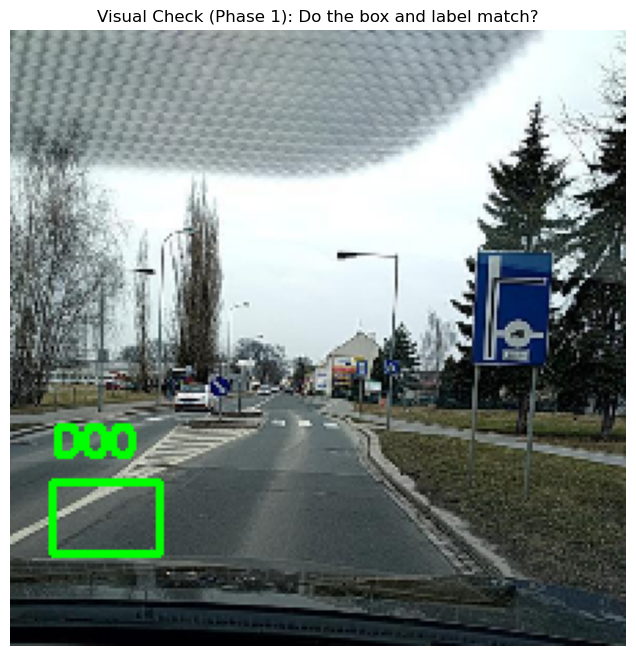

In [ ]:
import matplotlib.pyplot as plt

raw_data = parse_annotations(ANNOT_DIR, IMG_DIR, CLASS_MAP)
if not raw_data:
    print("Test Failed: Could not parse data. Check paths.")
else:
    df = pd.DataFrame(raw_data)
    train_df, _ = train_test_split(df, test_size=0.2, random_state=42)
    print(f"\nCreated training dataframe with {len(train_df)} samples.")

    # --- 4b. Instantiate Generator ---
    print("Instantiating RDD_DataGenerator1 (non-augmented)...")
    test_generator = RDD_DataGenerator1(
        dataframe=train_df,
        batch_size=BATCH_SIZE, # Using BATCH_SIZE=4 for this test
        target_size=IMG_SIZE,
        num_classes=NUM_CLASSES,
        shuffle=True
    )

    # --- 4c. Pull ONE Batch ---
    print("Manually pulling one batch (index 0)...")
    try:
        X_batch, y_batch_dict = test_generator[0]
        print("Successfully retrieved one batch!")
    except Exception as e:
        print(f"--- TEST FAILED: Error during __getitem__ ---")
        print(f"--- {e} ---")

    # --- 4d. Check Shapes and Data ---
    if 'X_batch' in locals():
        print("\n--- CHECKING BATCH OUTPUT ---")
        print(f"Images (X) shape:      {X_batch.shape}")
        print(f"Class (y) shape:       {y_batch_dict['classification_output'].shape}")
        print(f"Location (y) shape:    {y_batch_dict['localization_output'].shape}")

        print("\n--- CHECKING DATA RANGES ---")
        print(f"Image min/max:         {X_batch.min()} / {X_batch.max()}")
        print(f"Location min/max:      {y_batch_dict['localization_output'].min()} / {y_batch_dict['localization_output'].max()}")

        # --- 4e. VISUALIZE THE FIRST IMAGE ---
        print("\n--- VISUALIZING FIRST ITEM IN BATCH ---")

        img_to_show = (X_batch[0] * 255.0).astype(np.uint8)
        class_label_onehot = y_batch_dict['classification_output'][0]
        bbox_normalized = y_batch_dict['localization_output'][0]

        class_index = np.argmax(class_label_onehot)
        class_name = INT_TO_CLASS[class_index]

        h, w = IMG_SIZE
        xmin = int(bbox_normalized[0] * w)
        ymin = int(bbox_normalized[1] * h)
        xmax = int(bbox_normalized[2] * w)
        ymax = int(bbox_normalized[3] * h)

        img_with_box = img_to_show.copy()
        cv2.rectangle(img_with_box, (xmin, ymin), (xmax, ymax), (0, 255, 0), 2)
        cv2.putText(img_with_box, class_name, (xmin, ymin - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

        plt.figure(figsize=(8, 8))
        plt.imshow(img_with_box)
        plt.title("Visual Check (Phase 1): Do the box and label match?")
        plt.axis('off')
        plt.show()

Found 30224 XML files!
Warning! Invalid bbox in RDD_Dataset/annotations/xmls/Japan_001265.xml.
Parsing complete. Found 43777 valid damage annotations.
Total annotations found: 43778
Total annotations skipped: 10705
Image files not found: 0
XML parsing errors: 0

Created training dataframe with 35021 samples.
Instantiating RDD_DataGenerator2...
Manually pulling one batch of 32 images...
Successfully retrieved one batch!

Searching batch for augmented images...
Found a BRIGHTNESS/CONTRAST adjusted image at index 0. Plotting...


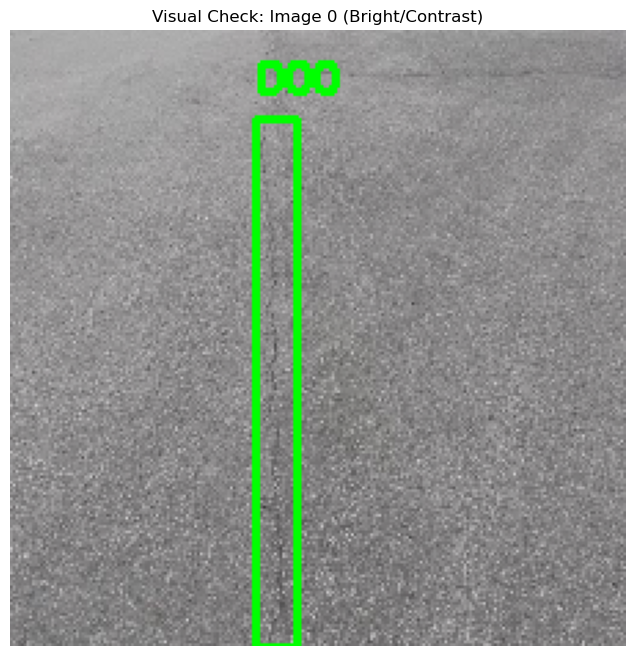

Found a HORIZONTALLY FLIPPED image at index 1. Plotting...


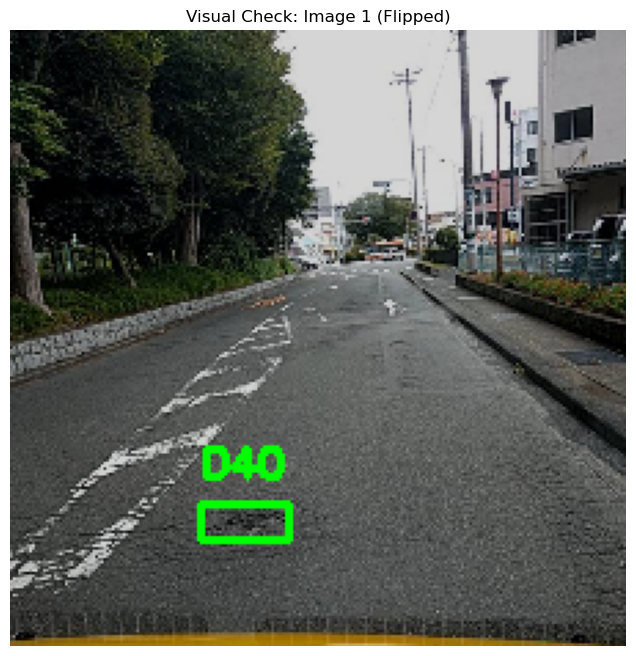


--- Augmentation Test Complete ---


In [ ]:
import matplotlib.pyplot as plt

raw_data = parse_annotations(ANNOT_DIR, IMG_DIR, CLASS_MAP)
if not raw_data:
    print("Test Failed: Could not parse data. Check paths.")
else:
    df = pd.DataFrame(raw_data)
    train_df, _ = train_test_split(df, test_size=0.2, random_state=42)
    print(f"\nCreated training dataframe with {len(train_df)} samples.")

    # 4b. Instantiate the SPECIAL Test Generator
    print("Instantiating RDD_DataGenerator2...")
    test_generator = RDD_DataGenerator2(
        dataframe=train_df,
        batch_size=BATCH_SIZE,
        target_size=IMG_SIZE,
        num_classes=NUM_CLASSES,
        shuffle=True,
        augment=True
    )

    # 4c. Pull ONE Batch
    print(f"Manually pulling one batch of {BATCH_SIZE} images...")
    try:
        (X_batch, y_batch_dict), debug_info = test_generator[0]
        print("Successfully retrieved one batch!")
    except Exception as e:
        print(f"--- TEST FAILED: Error during __getitem__ ---")
        print(e)

    # 4d. Loop to find and plot augmented images
    if 'X_batch' in locals():
        found_flipped = False
        found_brightened = False

        print("\nSearching batch for augmented images...")

        for i in range(BATCH_SIZE):
            img_to_show = (X_batch[i] * 255.0).astype(np.uint8)
            class_label_onehot = y_batch_dict['classification_output'][i]
            bbox_normalized = y_batch_dict['localization_output'][i]
            flags = debug_info[i]

            # --- Function to plot the image ---
            def plot_image(img, bbox_norm, class_onehot, title):
                class_index = np.argmax(class_onehot)
                class_name = INT_TO_CLASS[class_index]

                h, w = IMG_SIZE
                xmin = int(bbox_norm[0] * w)
                ymin = int(bbox_norm[1] * h)
                xmax = int(bbox_norm[2] * w)
                ymax = int(bbox_norm[3] * h)

                img_with_box = img.copy()
                cv2.rectangle(img_with_box, (xmin, ymin), (xmax, ymax), (0, 255, 0), 2)
                cv2.putText(img_with_box, class_name, (xmin, ymin - 10),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

                plt.figure(figsize=(8, 8))
                plt.imshow(img_with_box)
                plt.title(title)
                plt.axis('off')
                plt.show()
            # --- End of plot function ---

            # Find and plot one flipped image
            if flags["flipped"] and not found_flipped:
                print(f"Found a HORIZONTALLY FLIPPED image at index {i}. Plotting...")
                plot_image(img_to_show, bbox_normalized, class_label_onehot,
                           f"Visual Check: Image {i} (Flipped)")
                found_flipped = True

            # Find and plot one brightened image
            if flags["brightened"] and not found_brightened:
                print(f"Found a BRIGHTNESS/CONTRAST adjusted image at index {i}. Plotting...")
                plot_image(img_to_show, bbox_normalized, class_label_onehot,
                           f"Visual Check: Image {i} (Bright/Contrast)")
                found_brightened = True

            # Stop looping if we've found both
            if found_flipped and found_brightened:
                break

        if not found_flipped:
            print("NOTE: No horizontally flipped images were found in this random batch.")
        if not found_brightened:
            print("NOTE: No bright/contrast images were found in this random batch.")

        print("\n--- Augmentation Test Complete ---")